In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import h3

from ev_sim.shapely import *
from ev_sim.distance import distance

,daily_trips,daily_pmt,share_of_bike_trips,share_of_walk_trips,trips_per_sqmi,geoId,geometry,lat,lon,lon_min,lat_min,lon_max,lat_max
0,877.054,2255.613,2.980,9.265,8706.000,261614004003,"MULTIPOLYGON (((-83.73251 42.26441, -83.73132 ...",0.737623,-1.461325,-1.461426,0.737590,-1.461232,0.737657
1,821.542,4023.909,1.258,4.766,4528.000,261614126002,"MULTIPOLYGON (((-83.5738 42.2209, -83.57426 42...",0.736910,-1.458878,-1.459124,0.736841,-1.458630,0.737081
2,3857.773,17207.962,0.884,3.984,2628.000,261614031001,"MULTIPOLYGON (((-83.78089 42.31621, -83.78059 ...",0.738399,-1.462025,-1.462265,0.738244,-1.461637,0.738577
3,1306.538,5334.348,1.066,10.133,3555.000,261614127004,"MULTIPOLYGON (((-83.58194 42.21402, -83.5814 4...",0.736645,-1.458647,-1.458785,0.736578,-1.458355,0.736776
4,2182.298,10961.174,1.217,6.995,5359.000,261614026012,"MULTIPOLYGON (((-83.70887 42.30012, -83.70888 ...",0.738267,-1.460848,-1.460996,0.738188,-1.460711,0.738362


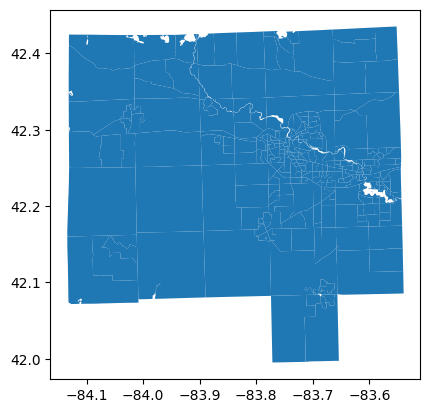

In [2]:
gdf = gpd.read_file("data/semcog/semcog_region-Blockgroup-20251120.geojson")

# gdf is a dataframe of geographical zones represented as MultiPolygons
# extract the centroids and lat/lon bounds of each zone
gdf["lat"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][1]))
gdf["lon"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][0]))
gdf[["lon_min", "lat_min", "lon_max", "lat_max"]] = gdf["geometry"].apply(
    lambda poly: np.radians(pd.Series(poly.bounds)))

# geoID has type object so we convert it to Int64
gdf["geoId"] = gdf["geoId"].astype("Int64")

ANN_ARBOR_ISLAND = {"type": "Polygon", "coordinates": [
    [[-83.78417372229106, 42.2816895426656], [-83.78442833090553, 42.26436540031527],
     [-83.78280893765309, 42.26008492559868], [-83.75582454773287, 42.23979620799212],
     [-83.74883466508147, 42.236735929136465], [-83.73855136330737, 42.23687482780095],
     [-83.71183498245512, 42.23740370837849], [-83.70811584123601, 42.23621391164227],
     [-83.68529280749691, 42.22525665336085], [-83.6857906858808, 42.23650010597878],
     [-83.6835321940817, 42.242004706064414], [-83.68404965774359, 42.25791215499742],
     [-83.68344560653675, 42.260914190143346], [-83.67688247678568, 42.26649675626558],
     [-83.67600732409866, 42.2715448988836], [-83.67658457439869, 42.28632696416514],
     [-83.67755868428011, 42.290614044749944], [-83.68167983910097, 42.2936145225612],
     [-83.686552450116, 42.297851548528804], [-83.68752346758508, 42.30527118507393],
     [-83.68752346758508, 42.311899477555414], [-83.68815019648227, 42.3176894192593],
     [-83.68965620128301, 42.321647402227995], [-83.69600286217157, 42.32340566372425],
     [-83.70765507180005, 42.32404585076619], [-83.72079679336368, 42.322860737478855],
     [-83.7330180068595, 42.32077168278856], [-83.73966360093908, 42.318253445137586],
     [-83.7425591296764, 42.31203821066514], [-83.7442414019795, 42.30786083796349],
     [-83.74416924569199, 42.30552504742622], [-83.74739360093946, 42.30038356346508],
     [-83.75116943638452, 42.29796820186064], [-83.76443176202858, 42.29866354272832],
     [-83.77387186604301, 42.30072283505719], [-83.78112975776224, 42.300962992494966],
     [-83.78872163001232, 42.29782791286006], [-83.79392203673349, 42.29357716043808],
     [-83.79792464908206, 42.290636920597954], [-83.80538664001456, 42.289349759963734],
     [-83.81290944838942, 42.28866651709263], [-83.79942756147045, 42.286966765791036],
     [-83.78751558920678, 42.284564616433606], [-83.78417372229106, 42.2816895426656]]]}

INTERCHANGES = [[-83.76428663584798, 42.24621291273493],
                [-83.73925818685441, 42.23706478179984],
                [-83.6856605166818, 42.225870502706016],
                [-83.68419888669358, 42.25478224069996],
                [-83.68758426002664, 42.30651664045945],
                [-83.74775152489084, 42.30070994562671],
                [-83.78733791729108, 42.29845959088495]]

OVERPASSES = [[-83.72025577918251, 42.23733842449474],
              [-83.69982464756285, 42.23235080877966],
              [-83.68561373145211, 42.230665232047656],
              [-83.68367416728648, 42.24553029362142],
              [-83.68273945396665, 42.2946569263457],
              [-83.70794793789851, 42.32405213628119],
              [-83.7354451631902, 42.319908790932466],
              [-83.76593721277933, 42.299095030528555],
              [-83.79970137211885, 42.29041832301253],
              [-83.78396890830167, 42.281680090237515],
              [-83.78442376681384, 42.27278069052162],
              [-83.77717033537063, 42.25620047726419]]

gdf.plot()
gdf.head()

In [3]:
df = pd.read_csv("data/semcog/SEMCOG_Person_Travel_2019_vs_2024_v14-599.csv")

AM_PEAK = 592  # 7am - 10am
MIDDAY = 593  # 10am - 3pm
PM_PEAK = 594  # 3pm - 7pm
OFF_PEAK = 595  # 7pm - 7am

WEEKDAY = 1
SATURDAY = 2
SUNDAY = 3

df["start_time"] = df["time_of_day"].map({AM_PEAK: 7, MIDDAY: 10, PM_PEAK: 15, OFF_PEAK: 19})
df["end_time"] = df["time_of_day"].map({AM_PEAK: 10, MIDDAY: 15, PM_PEAK: 19, OFF_PEAK: 31})  # 31:00 mod 24 = 7 AM
df["start_time"] *= 3600  # convert to seconds
df["end_time"] *= 3600  # convert to seconds

n = len(df)
df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
              left_on="origin_bg", right_on="geoId", how="inner")
df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
              left_on="destination_bg", right_on="geoId", how="inner", suffixes=("_pick", "_drop"))
assert n == len(df), f"Dropped {n - len(df)} rows when merging zone data to trips"

# split df into weekend and weekday, then repeat weekday df once for each weekday (0, ..., 4)
weekday_df = df[df["wday_type"] == WEEKDAY]
weekend_df = df[df["wday_type"] != WEEKDAY]
weekday_df = weekday_df.loc[weekday_df.index.repeat(5)].copy()  # repeat df once for each weekday
weekday_df["wday_type"] = np.tile(np.arange(0, 5),
                                  sum(df["wday_type"] == WEEKDAY))  # set wday_type to (0, 1, 2, 3, 4) repeated

weekend_df.loc[:, "wday_type"] = weekend_df["wday_type"].map({SATURDAY: 5, SUNDAY: 6})
df = pd.concat([weekday_df, weekend_df], ignore_index=True)  # combine weekend & weekday dfs

# sample number of daily trips from a Poisson distribution with mean daily_trips
rng = np.random.default_rng()
df["trips"] = rng.poisson(df["daily_trips"])
df = df.reindex(df.index.repeat(df["trips"]))

# sample trip start times
df["created_at"] = np.random.uniform(df["start_time"], df["end_time"])
df["created_at"] %= 24 * 3600  # modulo 24 hours
df["created_at"] += 24 * 3600 * df["wday_type"]
df["created_at"] = df["created_at"].astype("uint32")

df["pick_lat"] = np.random.uniform(low=df["lat_min_pick"], high=df["lat_max_pick"]).astype("float32")
df["pick_lon"] = np.random.uniform(low=df["lon_min_pick"], high=df["lon_max_pick"]).astype("float32")
df["drop_lat"] = np.random.uniform(low=df["lat_min_drop"], high=df["lat_max_drop"]).astype("float32")
df["drop_lon"] = np.random.uniform(low=df["lon_min_drop"], high=df["lon_max_drop"]).astype("float32")

df["pax"] = np.random.choice(np.arange(1, 5, dtype="uint8"), size=len(df), p=[0.775, 0.165, 0.040, 0.02])

df = df[df["created_at"] < 24 * 3600]
df.drop(["origin_bg", "destination_bg", "geoId_pick", "geoId_drop",
         "distance_mi", "daily_pmt", "daily_trips", "trips",
         "wday_type", "start_time", "end_time", "time_of_day",
         "lon_min_pick", "lat_min_pick", "lon_max_pick", "lat_max_pick",
         "lon_min_drop", "lat_min_drop", "lon_max_drop", "lat_max_drop"], axis=1, inplace=True)

print(len(df))
df.head()

959759


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax
0,34253,0.737471,-1.461561,0.738070,-1.461752,1
5,50841,0.737386,-1.461739,0.737364,-1.459930,2
5,38086,0.737439,-1.461791,0.737328,-1.460093,4
5,52112,0.737405,-1.461799,0.737400,-1.460026,1
5,50192,0.737401,-1.461871,0.737317,-1.459969,1


In [84]:
keplr_df = df.sample(n=50000)

keplr_df["pick_lat"] = np.degrees(keplr_df["pick_lat"])
keplr_df["pick_lon"] = np.degrees(keplr_df["pick_lon"])
keplr_df["drop_lat"] = np.degrees(keplr_df["drop_lat"])
keplr_df["drop_lon"] = np.degrees(keplr_df["drop_lon"])
keplr_df["created_at"] = pd.to_datetime(keplr_df["created_at"], unit="s", origin="2025-01-01 00:00")

keplr_df.to_parquet("output/semcog/washtenaw-trips.parquet")
keplr_df.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,lm_dist,pax
1657576,2025-01-08 16:37:30,42.283890,-83.787613,42.283176,-83.839195,5.974723,1
91380,2025-01-02 16:06:58,42.243286,-83.694405,42.260826,-83.738693,5.835285,1
610601,2025-01-03 19:36:02,42.277702,-83.758118,42.277180,-83.758072,0.646613,1
1071238,2025-01-05 14:16:20,42.155838,-84.051636,42.160164,-84.037819,2.145946,1
633838,2025-01-05 16:22:37,42.294376,-83.765053,42.272877,-83.744415,4.304232,1


In [133]:
keplr_df = clip_trips_to_region(df, ANN_ARBOR_ISLAND, keep_radians=False)

keplr_df = keplr_df.sample(n=50000)
keplr_df["created_at"] = pd.to_datetime(keplr_df["created_at"], unit="s", origin="2025-01-01 00:00")

keplr_df.to_parquet("output/semcog/ann-arbor-clipped-trips.parquet")
keplr_df.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,lm_dist,pax
1776276,2025-01-08 00:06:58,42.286373,-83.732780,42.275787,-83.734459,2.080388,1
339564,2025-01-06 08:12:24,42.277817,-83.736069,42.278324,-83.739487,0.937457,1
111815,2025-01-02 09:06:30,42.243130,-83.760262,42.274017,-83.734184,6.062090,1
759125,2025-01-02 10:37:15,42.276600,-83.745270,42.272964,-83.733292,1.928283,2
1617495,2025-01-08 13:26:40,42.243336,-83.683578,42.247505,-83.751762,10.060240,2


In [132]:
for mode in ("all", "internal", "inbound", "outbound"):
    keplr_df = snap_trips_to_boundary_points(df, ANN_ARBOR_ISLAND, INTERCHANGES + OVERPASSES, keep_radians=False,
                                             mode=mode)
    print(f"{mode} trips:", len(keplr_df))

    keplr_df = keplr_df.sample(frac=0.02)
    keplr_df["created_at"] = pd.to_datetime(keplr_df["created_at"], unit="s", origin="2025-01-01 00:00")

    keplr_df.to_parquet(f"output/semcog/{mode}-ann-arbor-trips.parquet")
    keplr_df.head()

all trips: 3346045
internal trips: 1933403
inbound trips: 715831
outbound trips: 696811


In [4]:
def vectorized_latlng_to_cell(lat, lon, res: int, is_radians: bool = True):
    if is_radians:
        lat = np.rad2deg(lat)
        lon = np.rad2deg(lon)

    cells = np.vectorize(h3.latlng_to_cell)(lat, lon, res)
    return np.vectorize(h3.str_to_int)(cells)

def preprocess_pings(df: pd.DataFrame, h3_res: int):
    df["pick_hex"] = vectorized_latlng_to_cell(df["pick_lat"], df["pick_lon"], h3_res)
    df["drop_hex"] = vectorized_latlng_to_cell(df["drop_lat"], df["drop_lon"], h3_res)

    df["predicted_lm_dist"] = distance(df["pick_lat"], df["pick_lon"], df["drop_lat"], df["drop_lon"])
    df.sort_values("created_at", inplace=True)

def preprocess_riders(df, h3_res: int):
    df["login_hex"] = vectorized_latlng_to_cell(df["lat"], df["lon"], h3_res)

In [5]:
H3_RESOLUTION = 6

pings = snap_trips_to_boundary_points(df, ANN_ARBOR_ISLAND, INTERCHANGES + OVERPASSES, mode="all")
preprocess_pings(pings, h3_res=H3_RESOLUTION)

pings.to_parquet("data/pings/ann-arbor.parquet")

print(pings.dtypes)
print(len(pings))
pings.head()

created_at            uint32
pick_lat             float32
pick_lon             float32
drop_lat             float32
drop_lon             float32
pax                    uint8
pick_hex               int64
drop_hex               int64
predicted_lm_dist    float32
dtype: object
532723


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist
58095,0,0.737485,-1.460565,0.737667,-1.461481,1,604233478107561983,604173502378934271,106.622574
417146,0,0.737667,-1.461359,0.737641,-1.461305,1,604173502378934271,604173502378934271,13.259884
324966,1,0.737943,-1.461485,0.737927,-1.461234,1,604173502378934271,604233477973344255,17.396503
437402,1,0.738326,-1.460975,0.737536,-1.461000,1,604233477973344255,604233478107561983,367.905151
313238,2,0.737682,-1.461159,0.738084,-1.461731,1,604233478107561983,604173502378934271,190.781296


In [49]:
for n_riders in (15000, 17500, 20000, 22500, 25000):
    riders = sample_points_in_polygon(ANN_ARBOR_ISLAND, n_riders, radians=True)
    riders["created_at"] = np.uint32(0)
    riders["lifetime"] = np.uint32(24 * 7 * 3600)
    preprocess_riders(riders, h3_res=H3_RESOLUTION)

    riders.to_parquet(f"data/riders/ann-arbor-{n_riders}.parquet")

print(riders.dtypes)
riders.head()

lat           float32
lon           float32
created_at     uint32
lifetime       uint32
login_hex       int64
dtype: object


,lat,lon,created_at,lifetime,login_hex
0,0.738606,-1.461440,0,604800,604233477973344255
1,0.737370,-1.461603,0,604800,604173502378934271
2,0.738434,-1.460647,0,604800,604233477973344255
3,0.737885,-1.462170,0,604800,604173502378934271
4,0.738207,-1.461112,0,604800,604233477973344255


In [124]:
INTERCHANGES_RAW = [
    {"type": "Polygon", "coordinates": [[[-83.7653053184995, 42.24695964710352], [-83.7653053184995, 42.24509281118205],
                                         [-83.76275861187068, 42.24509281118205],
                                         [-83.76275861187068, 42.24695964710352],
                                         [-83.7653053184995, 42.24695964710352]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.74015017566227, 42.23774097697641], [-83.74015017566227, 42.23605048903499],
         [-83.73792020364262, 42.23605048903499], [-83.73792020364262, 42.23774097697641],
         [-83.74015017566227, 42.23774097697641]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68660719232598, 42.22658232594573], [-83.68660719232598, 42.224802767846434],
         [-83.68424050321555, 42.224802767846434], [-83.68424050321555, 42.22658232594573],
         [-83.68660719232598, 42.22658232594573]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68519752285086, 42.25546774214873], [-83.68519752285086, 42.2537539885268],
         [-83.68270093245769, 42.2537539885268], [-83.68270093245769, 42.25546774214873],
         [-83.68519752285086, 42.25546774214873]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68857539500242, 42.307200975706685], [-83.68857539500242, 42.3054901375886],
         [-83.68609755756299, 42.3054901375886], [-83.68609755756299, 42.307200975706685],
         [-83.68857539500242, 42.307200975706685]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.74855035499152, 42.301261500288085], [-83.74855035499152, 42.29988261363462],
         [-83.74655327973984, 42.29988261363462], [-83.74655327973984, 42.301261500288085],
         [-83.74855035499152, 42.301261500288085]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.78825960166517, 42.299086240275884], [-83.78825960166517, 42.29751961679856],
         [-83.78595539072994, 42.29751961679856], [-83.78595539072994, 42.299086240275884],
         [-83.78825960166517, 42.299086240275884]]]}
]

OVERPASSES_RAW = [
    {"type": "Polygon", "coordinates": [
        [[-83.72065443320648, 42.237651471473384], [-83.72065443320648, 42.23686885402677],
         [-83.71965779814654, 42.23686885402677], [-83.71965779814654, 42.237651471473384],
         [-83.72065443320648, 42.237651471473384]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70013643938798, 42.23263938226738], [-83.70013643938798, 42.23191794854806],
         [-83.69935695982517, 42.23191794854806], [-83.69935695982517, 42.23263938226738],
         [-83.70013643938798, 42.23263938226738]]]},
    {"type": "Polygon", "coordinates": [[[-83.6860436272189, 42.2309475936862], [-83.6860436272189, 42.23024168958983],
                                         [-83.68496888780194, 42.23024168958983],
                                         [-83.68496888780194, 42.2309475936862],
                                         [-83.6860436272189, 42.2309475936862]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68403816600447, 42.24578228019548], [-83.68403816600447, 42.24515231376033],
         [-83.6831281692095, 42.24515231376033], [-83.6831281692095, 42.24578228019548],
         [-83.68403816600447, 42.24578228019548]]]},
    {"type": "Polygon", "coordinates": [[[-83.6831712809513, 42.29502296896619], [-83.6831712809513, 42.29410786241498],
                                         [-83.68209171348968, 42.29410786241498],
                                         [-83.68209171348968, 42.29502296896619],
                                         [-83.6831712809513, 42.29502296896619]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70828346106319, 42.32429627193206], [-83.70828346106319, 42.323685932804864],
         [-83.70744465315146, 42.323685932804864], [-83.70744465315146, 42.32429627193206],
         [-83.70828346106319, 42.32429627193206]]]},
    {"type": "Polygon", "coordinates": [[[-83.73583255375239, 42.32023765134], [-83.73583255375239, 42.31941550032116],
                                         [-83.73486407734694, 42.31941550032116], [-83.73486407734694, 42.32023765134],
                                         [-83.73583255375239, 42.32023765134]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.76626238447042, 42.2993415694097], [-83.76626238447042, 42.29872522220684],
         [-83.76544945524273, 42.29872522220684], [-83.76544945524273, 42.2993415694097],
         [-83.76626238447042, 42.2993415694097]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.80025005101768, 42.29079492822921], [-83.80025005101768, 42.289853415187515],
         [-83.7988783537706, 42.289853415187515], [-83.7988783537706, 42.29079492822921],
         [-83.80025005101768, 42.29079492822921]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78337787301311, 42.28208581687849], [-83.78485546123454, 42.28208581687849],
         [-83.78485546123454, 42.28107150027606], [-83.78337787301311, 42.28107150027606],
         [-83.78337787301311, 42.28208581687849]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78480983499519, 42.27312583402841], [-83.78480983499519, 42.27226297526143],
         [-83.78384466454183, 42.27226297526143], [-83.78384466454183, 42.27312583402841],
         [-83.78480983499519, 42.27312583402841]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.77661422170391, 42.256574286289904], [-83.77800450587073, 42.256574286289904],
         [-83.77800450587073, 42.255639763725604], [-83.77661422170391, 42.255639763725604],
         [-83.77661422170391, 42.256574286289904]]]},
]

for interchange in OVERPASSES_RAW:
    lons, lats = zip(*interchange["coordinates"][0])
    mean_lon = np.mean(lons)
    mean_lat = np.mean(lats)
    print(f"[{mean_lon}, {mean_lat}],")

[-83.72025577918251, 42.23733842449474],
[-83.69982464756285, 42.23235080877966],
[-83.68561373145211, 42.230665232047656],
[-83.68367416728648, 42.24553029362142],
[-83.68273945396665, 42.2946569263457],
[-83.70794793789851, 42.32405213628119],
[-83.7354451631902, 42.319908790932466],
[-83.76593721277933, 42.299095030528555],
[-83.79970137211885, 42.29041832301253],
[-83.78396890830167, 42.281680090237515],
[-83.78442376681384, 42.27278069052162],
[-83.77717033537063, 42.25620047726419],
